In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

data/train.parquet
data/test.parquet
data/target_channels.csv
data/sample_submission.parquet
data/preprocessed/datasets.csv


In [2]:
# Load channels 41-46 and ground truth from the training set
channel_names = [f"channel_{x}" for x in range(41,46 + 1)]
columns_to_load = ["id"] + channel_names + ["is_anomaly"]
train_df = pd.read_parquet("data/train.parquet", columns=columns_to_load)
train_df

,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46,is_anomaly
0,0,0.812578,0.786344,0.771900,0.799178,0.816855,0.765296,0
1,1,0.812578,0.786344,0.771900,0.799178,0.816855,0.765296,0
2,2,0.821213,0.789557,0.770317,0.809411,0.816006,0.765296,0
3,3,0.819642,0.786344,0.770317,0.807050,0.816855,0.766985,0
4,4,0.821996,0.788753,0.770317,0.807837,0.818551,0.761073,0
...,...,...,...,...,...,...,...,...
14728316,14728316,0.806299,0.799999,0.767944,0.792093,0.821094,0.752628,0
14728317,14728317,0.806299,0.790360,0.765569,0.792881,0.821941,0.763607,0
14728318,14728318,0.806299,0.795180,0.765569,0.792881,0.822790,0.762762,0
14728319,14728319,0.806299,0.796786,0.767152,0.796816,0.820247,0.761073,0


In [3]:
# Calculate mean and std of nominal samples for each channel
train_nominal_data = train_df.loc[train_df["is_anomaly"] == 0, channel_names].values
means = np.mean(train_nominal_data, axis=0)
stds = np.std(train_nominal_data, axis=0)
means, stds

(array([0.8097887 , 0.78368527, 0.7702863 , 0.7959557 , 0.81196404,
        0.76715434], dtype=float32),
 array([0.00520087, 0.0070754 , 0.00546598, 0.00611251, 0.00583273,
        0.00710337], dtype=float32))

In [4]:
# Load test set
test_df = pd.read_parquet("data/test.parquet", columns=["id"] + channel_names)
test_df

,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46
0,14728321,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
1,14728322,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
2,14728323,0.808654,0.792770,0.763195,0.795242,0.821094,0.753472
3,14728324,0.806299,0.791966,0.765569,0.796030,0.820247,0.763607
4,14728325,0.809439,0.799195,0.763195,0.796816,0.821941,0.760229
...,...,...,...,...,...,...,...
521275,15249596,0.801590,0.794377,0.763987,0.788945,0.819398,0.760229
521276,15249597,0.803160,0.795180,0.764778,0.792093,0.818551,0.762762
521277,15249598,0.804729,0.796786,0.763987,0.790520,0.816006,0.763607
521278,15249599,0.806299,0.789557,0.763987,0.792881,0.816855,0.757695


In [5]:
# Find test samples with values outside of (mean ± N * std) for any channel
N = 3
test_data = test_df.loc[:, channel_names]
detections = (test_data > (means + N * stds)) | (test_data < (means - N * stds))
aggregated_detections = detections.max(axis=1).astype(np.uint8)

In [6]:
# Save to submission file
submission_df = pd.DataFrame(columns=["id", "is_anomaly"])
submission_df["id"] = test_df["id"]
submission_df["is_anomaly"] = aggregated_detections
submission_df.to_parquet(f"data/output/GlobalSTD{N}-channels41-46.parquet")
# Generate a file supported by the Kaggle "Submit to competition" option
submission_df.to_csv(f"data/output/submission.csv", index=False)

<Axes: title={'center': 'Results for N=3'}, xlabel='id'>

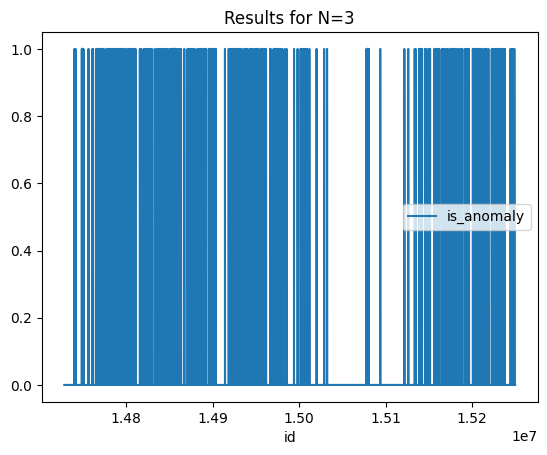

In [7]:
submission_df.plot("id", "is_anomaly", title=f"Results for N={N}")

In [8]:
# Try with different N
N = 5
detections = (test_data > (means + N * stds)) | (test_data < (means - N * stds))
aggregated_detections = detections.max(axis=1).astype(np.uint8)
submission_df["is_anomaly"] = aggregated_detections
submission_df.to_parquet(f"/kaggle/working/GlobalSTD{N}-channels41-46.parquet")

<Axes: title={'center': 'Results for N=5'}, xlabel='id'>

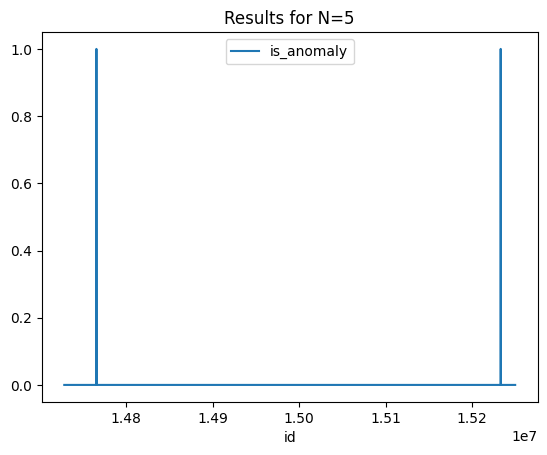

In [9]:
submission_df.plot("id", "is_anomaly", title=f"Results for N={N}")